 # Diagramas de arquitectura del modelo denso con la SNR



 Figuras de la arquitectura del modelo entrenado en `snr_training.ipynb`, para la memoria. Las dibuja `services/architecture_diagram.py`, el módulo que comparten todos los cuadernos de diagramas de `models`:



 - La vista `graph` que **visualkeras** saca del modelo ya entrenado, sin escribir la estructura a mano.



 Este modelo es la red densa de `dense_training.ipynb` con **la SNR del espectro de Gaia añadida a la entrada**: las capas son exactamente las mismas y lo único que cambia es que la entrada pasa de 201 a 402 números. La celda siguiente lo comprueba contra los dos modelos entrenados.



 La arquitectura descrita es la de `snr_training.ipynb`, así que hay que repasarla si cambia la red.

In [1]:
import sys

from pathlib import Path

# 'services' está tanto en 'solution' como en 'models', así que las dos carpetas
# van a 'sys.path'. 'solution' se localiza subiendo desde el directorio de
# trabajo, sin suponer dónde arranca el kernel: su marca es 'pyproject.toml'.
DIRECTORIES = (Path.cwd(), *Path.cwd().parents)
CANDIDATES = (*DIRECTORIES, *(directory / "solution" for directory in DIRECTORIES))
SOLUTION_DIR = next(
    candidate for candidate in CANDIDATES if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))
sys.path.insert(0, str(SOLUTION_DIR))

from services.architecture_diagram import DIAGRAMS_DIR, draw_diagrams, layer_signature
from services.paths import model_paths

# El modelo a dibujar y el denso con el que se compara
MODEL_PATH = model_paths("snr", "snr").model
DENSE_MODEL_PATH = model_paths("dense-median", "dense").model

print("Carpeta de trabajo:", SOLUTION_DIR)
print("Figuras en:", DIAGRAMS_DIR)


2026-09-06 11:55:52.829051: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-06 11:55:52.959432: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-06 11:55:55.615562: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution
Figuras en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams


 El `.keras` guarda la arquitectura junto con los pesos. El resumen sirve para comprobar contra el modelo entrenado las formas y el número de neuronas que se describen aquí. La vista de visualkeras sí sale del modelo cargado.



 La comparación con el modelo denso se hace sobre la clase y la forma de salida de cada capa: es justamente la entrada lo que distingue a las dos redes, y el resto tiene que coincidir para que lo que aquí se describe sea cierto.

In [2]:
import tensorflow as tf

model_snr = tf.keras.models.load_model(MODEL_PATH)
model_dense = tf.keras.models.load_model(DENSE_MODEL_PATH)

# Las dos redes son la misma salvo por la entrada, que aquí lleva la SNR
# concatenada al espectro, y esta descripción solo vale si es cierto
assert layer_signature(model_snr) == layer_signature(model_dense), (
    layer_signature(model_snr), layer_signature(model_dense)
)
assert model_snr.inputs[0].shape[1] == 2 * model_dense.inputs[0].shape[1]

model_snr.summary()


2026-09-06 11:55:57.041224: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       206,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,690,496 (63.67 MB)

 Trainable params: 5,563,498 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,126,998 (42.45 MB)

 La arquitectura de la red es la siguiente:



 - La entrada son **402 números**: los 201 puntos del espectro XP de Gaia y, concatenados detrás, los 201 valores de la SNR de ese mismo espectro. Cada mitad se normaliza a su manera antes de entrar en la red: el espectro se divide entre la mediana de su flujo absoluto, espectro a espectro, mientras que la SNR se tipifica punto a punto con la media y la desviación típica del conjunto de entrenamiento.

 - Las **cuatro capas ocultas** —una de 512 y tres de 1024, alternando `LeakyReLU` con pendiente 0,01 y `ELU`— y la **salida lineal de 2666** son exactamente las del modelo denso. La red no sabe que la segunda mitad de su entrada es una medida de calidad y no un flujo: eso tiene que aprenderlo de los datos, como cualquier otra relación entre las entradas.

 - Los 201 números de más de la entrada añaden 103 000 parámetros a la primera capa oculta, un 1,9 % de los 5,56 millones del modelo. Es todo el coste de la prueba.



 Y cómo se lee la vista `graph` de visualkeras, que salen del `.keras` y por tanto enseñan la red tal y como quedó y no como se pretendía que fuera:



 - `graph`: las neuronas de cada capa y las conexiones entre ellas, resumidas con puntos suspensivos.

Diagrama guardado en: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/snr_graph-diagram.png


/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/services/architecture_diagram.py:347: UserWarning: graph_view received many custom keyword arguments. Consider using visualkeras.show(..., mode='graph', preset=...) and the GraphOptions dataclass for a simpler workflow.
  render(


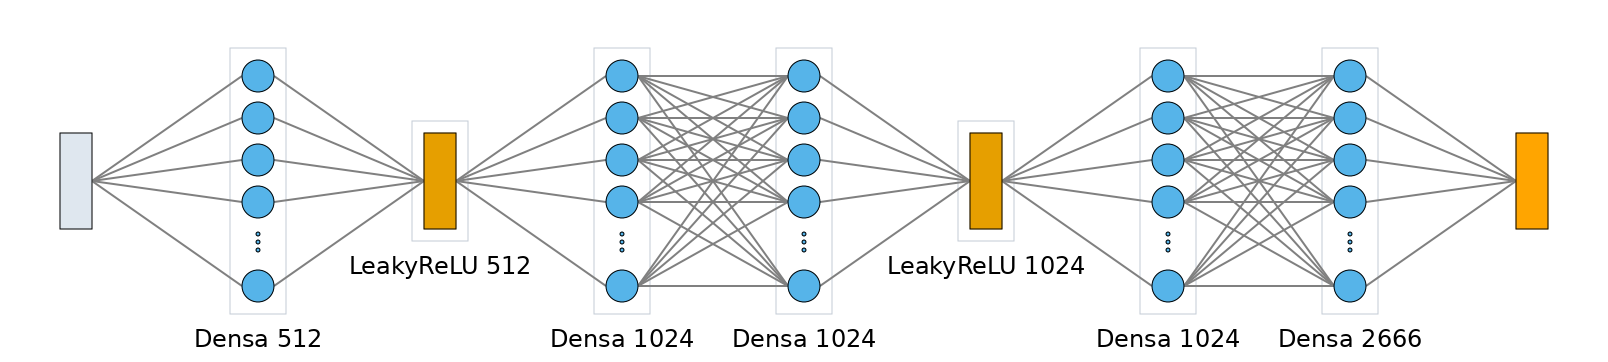

{'graph': PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/architectural_diagrams/snr_graph-diagram.png')}

In [3]:
# Las columnas, apretadas como las de la red densa: es la misma red y sus pies
# son igual de cortos
draw_diagrams(model_snr, "snr", graph={"layer_spacing": 150})
